# **BEV 3D Keypoints Anthro Distance**

## **Pipeline**
* Use BEV to get 2D keypoints (pixel coordinates) and 3D keypoints (unscaled camera coordinates)
* Calculate trunk height given ground truth coordinates (only used for this calculation)
* Transform keypoints based on torso measurements
* Convert 3D keypoints to Unreal Engine camera coordinates
* Render pose visualization
* Compute output vectors

### **Setup**

```
conda create -n fbv-bev python=3.9
conda activate fbv-bev
conda install matplotlib
pip install mediapipe opencv-python
pip install ipympl
conda install ipykernel=6.29.5
```

In [1]:
import bev
import cv2
import numpy as np
import json
import time
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [3]:
%matplotlib widget

In [4]:
IMAGE_A_PATH = "../../../dataset/images_A/00007A.png"
IMAGE_B_PATH = "../../../dataset/images_B/00007B.png"
JSON_A_PATH = "../../../dataset/metadata_A/00007A.json"
MODEL_PATH = "../../models/pose_landmarker_full.task"

FOCAL_LENGTH_MM = 35.0
SENSOR_WIDTH_MM = 36.0 
BASELINE_M = 0.1

### **BEV Initialization**

In [5]:
# Configure BEV Settings

settings = bev.main.default_settings
settings.mode = 'image'
settings.render_mesh = False  # Skip the 3D mesh creation
settings.show = False         # Skip opening a display window
settings.save_dict = False    # Skip saving .npz files to disk

In [6]:
# Load BEV Model

bev_model = bev.BEV(settings)

Using BEV.
Threshold for positive center detection: 0.08


In [7]:
def get_output(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    
    outputs = bev_model(img)
        
    return outputs

### **Run Inference**

In [8]:
# Run Model On Given File

image_file = IMAGE_A_PATH
start_time = time.perf_counter()

outputs = get_output(image_file)

joints = outputs['joints']
if hasattr(joints, 'detach'):
    joints =  data.detach().cpu().numpy()

end_time = time.perf_counter()

if joints is not None:
    print(f"Detected {len(joints)} people.")
    print(f"First person Pelvis (X, Y, Z): {joints[0][0]}")

execution_time = end_time - start_time
print(f"Detection took: {execution_time:.4f} seconds")
print(f"FPS: {1/execution_time:.2f}")

Detected 1 people.
First person Pelvis (X, Y, Z): [-0.00757504  0.02569653 -0.01918705]
Detection took: 1.4426 seconds
FPS: 0.69


In [9]:
#   Get 2D Keypoints

def get_normalized_2d_keypoints(outputs, person_idx=0):
    cam = outputs['cam'][person_idx]
    if hasattr(cam, 'detach'):
        cam = cam.detach().cpu().numpy()
        
    scale = cam[0]
    trans = cam[1:3]

    joints_3d = outputs['joints'][person_idx]
    if hasattr(joints_3d, 'detach'):
        joints_3d = joints_3d.detach().cpu().numpy()
    
    kp2d_ndc = scale * (joints_3d[:, :2] + trans)

    keypoints_2d_norm = (kp2d_ndc + 1.0) / 2.0
    
    return keypoints_2d_norm

keypoints_2d = get_normalized_2d_keypoints(outputs)

### **Visualization**

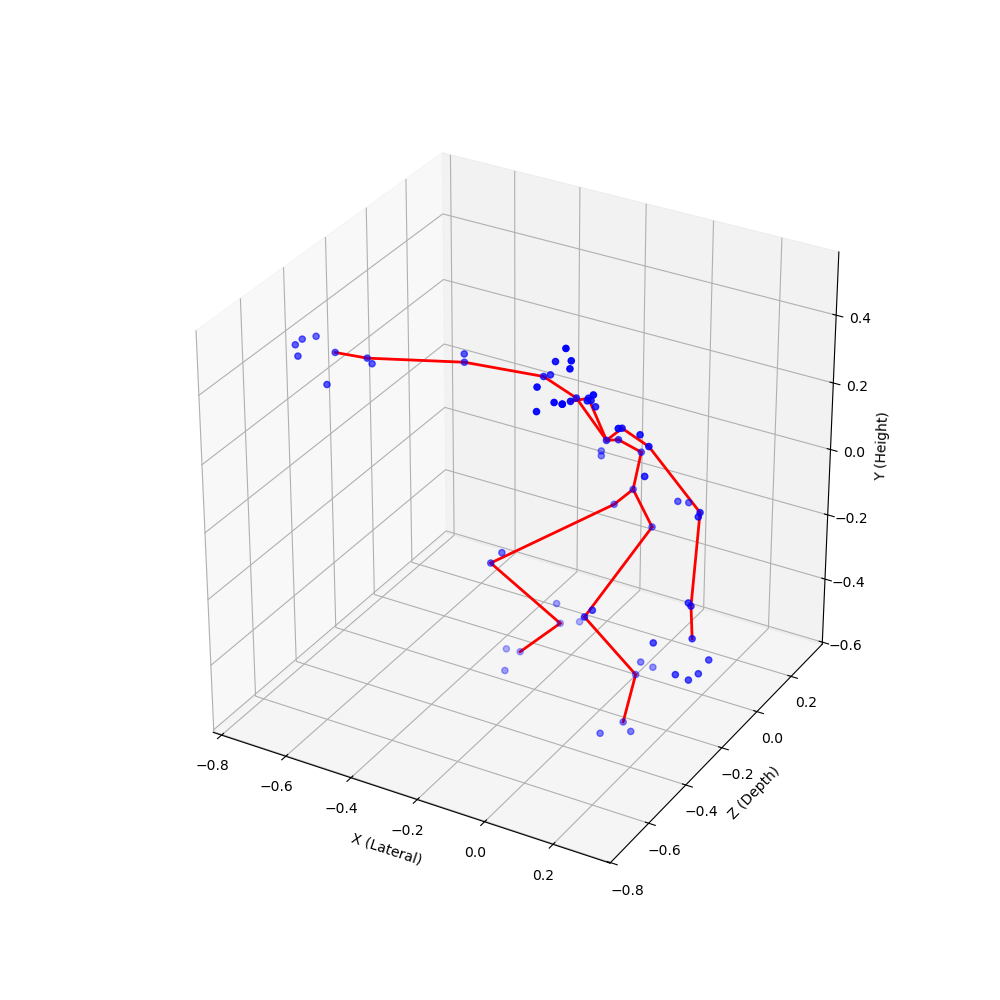

In [10]:
# Show 3D Coordinates

def plot_bev_skeleton(joints_3d, person_idx=0):
    person_joints = np.array(joints_3d[person_idx]).astype(float)
    if np.isnan(person_joints).any():
        person_joints = np.nan_to_num(person_joints)

    smpl_connections = [
        (0, 1), (0, 2), (0, 3), (1, 4), (4, 7), (7, 10), (2, 5), (5, 8), (8, 11),
        (3, 6), (6, 9), (9, 12), (12, 15), (9, 13), (13, 16), (16, 18), (18, 20),
        (20, 22), (9, 14), (14, 17), (17, 19), (19, 21), (21, 23)
    ]

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    x = person_joints[:, 0]
    y = -person_joints[:, 1]
    z = person_joints[:, 2]

    mid_x = (x.max() + x.min()) * 0.5
    mid_y = (y.max() + y.min()) * 0.5
    mid_z = (z.max() + z.min()) * 0.5
    max_range = np.array([x.max()-x.min(), y.max()-y.min(), z.max()-z.min()]).max() / 2.0

    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_z - max_range, mid_z + max_range)
    ax.set_zlim(mid_y - max_range, mid_y + max_range)

    ax.set_box_aspect([1,1,1]) 

    ax.scatter(x, z, y, c='blue', s=20)

    for start, end in smpl_connections:
        ax.plot([x[start], x[end]], [z[start], z[end]], [y[start], y[end]], c='red', linewidth=2)

    ax.set_xlabel('X (Lateral)')
    ax.set_ylabel('Z (Depth)')
    ax.set_zlabel('Y (Height)')
    
    plt.show()

if joints is not None:
    plot_bev_skeleton(joints, person_idx=0)

In [11]:
print(joints.shape)

(1, 71, 3)


### **Convert To Numpy**

In [12]:
# Create Numpy Arrays

keypoints_3d = joints[0].copy()

### **Calculate Torso Measurements**

In [13]:
# Load JSON Metadata

with open(JSON_A_PATH, 'r') as file:
    raw_data = json.load(file)

data = {
    'RS': np.array([raw_data['Right Shoulder Coords'][axis] for axis in ['x', 'y', 'z']]),
    'LS': np.array([raw_data['Left Shoulder Coords'][axis] for axis in ['x', 'y', 'z']]),
    'RT': np.array([raw_data['Right Thigh Coords'][axis] for axis in ['x', 'y', 'z']]),
    'LT': np.array([raw_data['Left Thigh Coords'][axis] for axis in ['x', 'y', 'z']]),
    'RW': np.array([raw_data['Right Wrist Coords'][axis] for axis in ['x', 'y', 'z']]),
}

print(data)

{'RS': array([-2285.95959859,   -37.81550278,   128.70578003]), 'LS': array([-2314.04039293,   -37.81549369,   128.70578003]), 'RT': array([-2290.42792601,   -42.311687  ,    87.02477629]), 'LT': array([-2309.57207007,   -42.31169027,    87.02479981]), 'RW': array([-2260.20332508,   -68.95848476,   152.15760463])}


In [14]:
# Get Ground Truth Torso Measurements

shoulder_midpoint = (data['RS'] + data['LS']) / 2
thigh_midpoint = (data['RT'] + data['LT']) / 2

shoulder_width = np.linalg.norm(data['RS'] - data['LS'])
thigh_width = np.linalg.norm(data['RT'] - data['LT'])
arm_length = np.linalg.norm(data['RS'] - data['RW'])
torso_height = np.linalg.norm(shoulder_midpoint - thigh_midpoint)

print(shoulder_width)
print(thigh_width)
print(arm_length)
print(torso_height)

28.080794334405816
19.144144058242265
46.725357451431464
41.92279594946382


### **Transform Keypoints**

In [15]:
# Get Predicted Torso Measurements

L_SHOULDER, R_SHOULDER = 16, 17
L_HIP, R_HIP = 1, 2
R_WRIST = 21

model_shoulder_dist = np.linalg.norm(keypoints_3d[L_SHOULDER] - keypoints_3d[R_SHOULDER])*100
model_arm_length = np.linalg.norm(keypoints_3d[R_WRIST] - keypoints_3d[R_SHOULDER])*100

model_shoulder_mid = (keypoints_3d[L_SHOULDER] + keypoints_3d[R_SHOULDER]) / 2
model_hip_mid = (keypoints_3d[L_HIP] + keypoints_3d[R_HIP]) / 2
model_torso_height = np.linalg.norm(model_shoulder_mid - model_hip_mid)*100

print(model_shoulder_dist)
print(model_arm_length)
print(model_torso_height)

34.80222
48.212196
48.37804


In [16]:
# Compute Scale Factor

ratios = [
    shoulder_width / model_shoulder_dist,
    arm_length     / model_arm_length,
    torso_height   / model_torso_height
]

scale_factor = np.median(ratios)
print(scale_factor)

0.8665666421707849


In [17]:
# Scale 3D Keypoints

keypoints_3d_cm = keypoints_3d * 100 * scale_factor

In [18]:
# Calculate Pixel Focal Length

IMAGE_WIDTH_PX, IMAGE_HEIGHT_PX = 1920, 1080
focal_length_px= (FOCAL_LENGTH_MM * IMAGE_WIDTH_PX) / SENSOR_WIDTH_MM

In [19]:
# Get Pixel Distances

def get_pix_dist(idx1, idx2):
    p1 = keypoints_2d[idx1] * [IMAGE_WIDTH_PX, IMAGE_HEIGHT_PX]
    p2 = keypoints_2d[idx2] * [IMAGE_WIDTH_PX, IMAGE_HEIGHT_PX]
    return np.linalg.norm(p1 - p2)

sh_mid_2d = (keypoints_2d[L_SHOULDER] + keypoints_2d[R_SHOULDER]) / 2 * [IMAGE_WIDTH_PX, IMAGE_HEIGHT_PX]
hi_mid_2d = (keypoints_2d[L_HIP] + keypoints_2d[R_HIP]) / 2 * [IMAGE_WIDTH_PX, IMAGE_HEIGHT_PX]

pixels_shoulders = get_pix_dist(L_SHOULDER, R_SHOULDER)
pixels_arm = get_pix_dist(R_SHOULDER, R_WRIST)
pixels_torso = np.linalg.norm(sh_mid_2d - hi_mid_2d)

In [20]:
# Calculate Distances

z_estimates = [
    (np.linalg.norm(keypoints_3d_cm[L_SHOULDER] - keypoints_3d_cm[R_SHOULDER]) * focal_length_px) / pixels_shoulders,
    (np.linalg.norm(keypoints_3d_cm[R_SHOULDER] - keypoints_3d_cm[R_WRIST]) * focal_length_px) / pixels_arm,
    (np.linalg.norm(model_shoulder_mid*100*scale_factor - model_hip_mid*100*scale_factor) * focal_length_px) / pixels_torso
]

final_z_distance_cm = np.median(z_estimates)

hip_center_2d = (keypoints_2d[L_HIP] + keypoints_2d[R_HIP]) / 2
pixel_x_offset = (hip_center_2d[0] * IMAGE_WIDTH_PX) - (IMAGE_WIDTH_PX / 2)
pixel_y_offset = (hip_center_2d[1] * IMAGE_HEIGHT_PX) - (IMAGE_HEIGHT_PX / 2)

final_x_distance_cm = (pixel_x_offset * final_z_distance_cm) / focal_length_px
final_y_distance_cm = (pixel_y_offset * final_z_distance_cm) / focal_length_px

In [21]:
# Transform To Camera Coordinates

transformed_keypoints_3d = keypoints_3d_cm.copy()
transformed_keypoints_3d[:, 0] += final_x_distance_cm
transformed_keypoints_3d[:, 1] += final_y_distance_cm
transformed_keypoints_3d[:, 2] += final_z_distance_cm
transformed_keypoints_3d /= 100

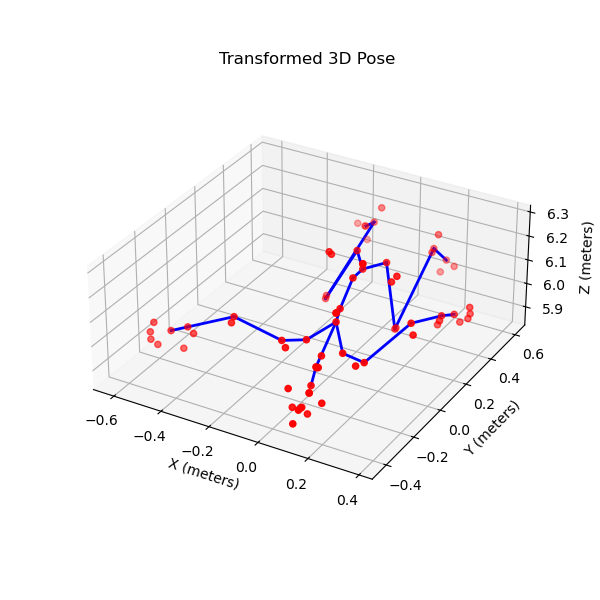

In [22]:
# Visualize Transformed 3D Keypoints

def plot_pose_3d(points_3d):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], c='r', marker='o')

    smpl_connections = [
        (0, 1), (0, 2), (0, 3), (1, 4), (4, 7), (7, 10), (2, 5), (5, 8), (8, 11),
        (3, 6), (6, 9), (9, 12), (12, 15), (9, 13), (13, 16), (16, 18), (18, 20),
        (20, 22), (9, 14), (14, 17), (17, 19), (19, 21), (21, 23)
    ]

    for connection in smpl_connections:
        start_idx, end_idx = connection
        if start_idx < len(points_3d) and end_idx < len(points_3d):
            xs = [points_3d[start_idx, 0], points_3d[end_idx, 0]]
            ys = [points_3d[start_idx, 1], points_3d[end_idx, 1]]
            zs = [points_3d[start_idx, 2], points_3d[end_idx, 2]]
            ax.plot(xs, ys, zs, c='b', linewidth=2)

    ax.set_aspect('equal')
    ax.set_xlabel('X (meters)')
    ax.set_ylabel('Y (meters)')
    ax.set_zlabel('Z (meters)')
    ax.set_title('Transformed 3D Pose')
    
    plt.show()

plot_pose_3d(transformed_keypoints_3d)

### **Convert To Unreal Engine Coordinates**

In [23]:
# Apply Coordinate Conversion

def convert_to_unreal_coords(points_3d_meters):
    unreal_pts = np.zeros_like(points_3d_meters)
    
    # UE X (Forward) = CV Z
    unreal_pts[:, 0] = points_3d_meters[:, 2] * 100
    
    # UE Y (Right) = CV X
    unreal_pts[:, 1] = points_3d_meters[:, 0] * 100
    
    # UE Z (Up) = -CV Y
    unreal_pts[:, 2] = -points_3d_meters[:, 1] * 100
    
    return unreal_pts

ue_keypoints_3d = convert_to_unreal_coords(transformed_keypoints_3d)

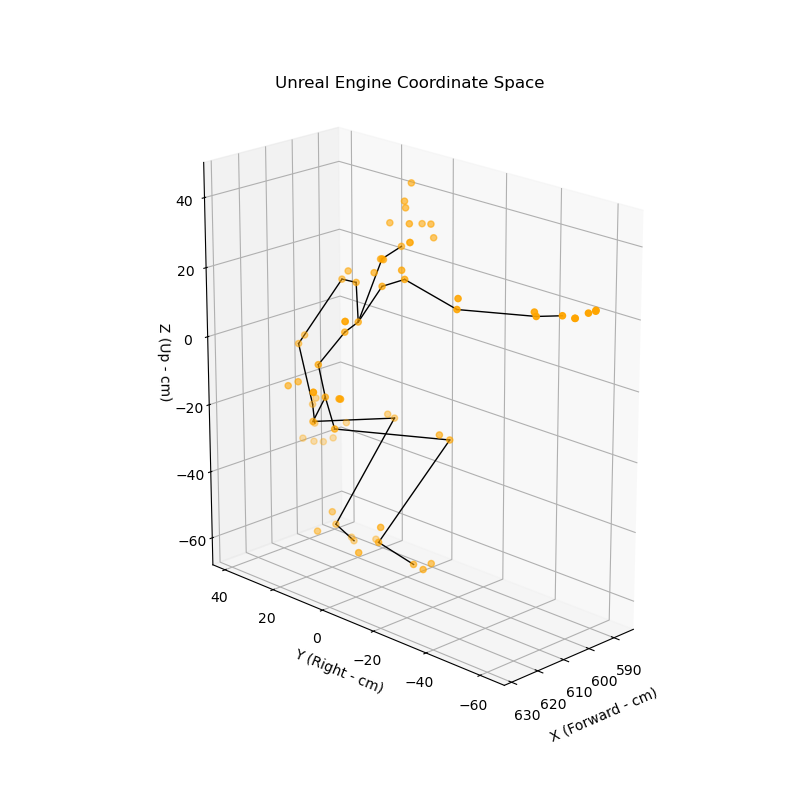

In [24]:
# Verify Coordinate Conversion

def plot_pose_unreal_3d(points_3d):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], c='orange', marker='o')
    
    smpl_connections = [
        (0, 1), (0, 2), (0, 3), (1, 4), (4, 7), (7, 10), (2, 5), (5, 8), (8, 11),
        (3, 6), (6, 9), (9, 12), (12, 15), (9, 13), (13, 16), (16, 18), (18, 20),
        (20, 22), (9, 14), (14, 17), (17, 19), (19, 21), (21, 23)
    ]

    for connection in smpl_connections:
        start_idx, end_idx = connection
        if start_idx < len(points_3d) and end_idx < len(points_3d):
            xs = [points_3d[start_idx, 0], points_3d[end_idx, 0]]
            ys = [points_3d[start_idx, 1], points_3d[end_idx, 1]]
            zs = [points_3d[start_idx, 2], points_3d[end_idx, 2]]
            ax.plot(xs, ys, zs, c='black', linewidth=1)

    ax.set_xlabel('X (Forward - cm)')
    ax.set_ylabel('Y (Right - cm)')
    ax.set_zlabel('Z (Up - cm)')
    ax.set_title('Unreal Engine Coordinate Space')

    ax.set_aspect('equal')
    ax.invert_yaxis()
    
    ax.view_init(elev=20, azim=45)
    
    plt.show()

plot_pose_unreal_3d(ue_keypoints_3d)

### **Compute Output Vector**

In [25]:
# Given Constants

camera_coords = np.array([0, 0, 0])
world_up = np.array([0, 0, 1])
camera_pitch_rad = np.deg2rad(-56.21609944105149)

In [26]:
# Get Right Shoulder & Wrist Coordinates

shoulder_coords = ue_keypoints_3d[17]
wrist_coords = ue_keypoints_3d[21]

print(shoulder_coords)
print(wrist_coords)

[607.21839369  -6.40957254  22.61902366]
[599.23340673 -47.33315445  19.97488204]


In [27]:
# Shoulder-Camera Distance

distance = np.linalg.norm(shoulder_coords)
print(distance, "cm")

607.673333697318 cm


In [28]:
# Shoulder-Wrist Shoulder-Camera Vectors

shoulder_wrist = wrist_coords - shoulder_coords
shoulder_wrist /= np.linalg.norm(shoulder_wrist)

shoulder_camera = camera_coords - shoulder_coords
shoulder_camera /= np.linalg.norm(shoulder_camera)

print(shoulder_wrist)
print(shoulder_camera)

[-0.19112408 -0.97952342 -0.06328866]
[-0.99925134  0.01054773 -0.03722234]


In [29]:
# Angular Separation

angular_separation_rad = np.arccos(np.clip(np.dot(shoulder_wrist, shoulder_camera), -1.0, 1.0))
angular_separation_deg = np.rad2deg(angular_separation_rad)

print(angular_separation_deg, "deg")


79.45515858609743 deg


In [30]:
# Camera Un-Pitch Matrix (Aligns Z-Axis with Gravity)

c, s = np.cos(-camera_pitch_rad), np.sin(-camera_pitch_rad)
unpitch_matrix = np.array([
    [c,  0, s],
    [0,  1, 0],
    [-s, 0, c]
])
print(unpitch_matrix)

[[ 0.5560621   0.          0.83114075]
 [ 0.          1.          0.        ]
 [-0.83114075  0.          0.5560621 ]]


In [31]:
# Un-Pitch Vectors

shoulder_wrist_gravity = unpitch_matrix @ shoulder_wrist
shoulder_wrist_gravity /= np.linalg.norm(shoulder_wrist_gravity)

shoulder_camera_gravity = unpitch_matrix @ shoulder_camera
shoulder_camera_gravity /= np.linalg.norm(shoulder_camera_gravity)

print(shoulder_wrist_gravity)
print(shoulder_camera_gravity)

[-0.15887864 -0.97952342  0.12365858]
[-0.5865828   0.01054773  0.80982058]


In [32]:
# Yaw & Pitch Components

shoulder_wrist_gravity_yaw = np.rad2deg(np.atan2(shoulder_wrist_gravity[1], shoulder_wrist_gravity[0]))
shoulder_wrist_gravity_pitch = np.rad2deg(np.asin(np.clip(shoulder_wrist_gravity[-1], -1.0, 1.0)))

shoulder_camera_gravity_yaw = np.rad2deg(np.atan2(shoulder_camera_gravity[1], shoulder_camera_gravity[0]))
shoulder_camera_gravity_pitch = np.rad2deg(np.asin(np.clip(shoulder_camera_gravity[-1], -1.0, 1.0)))

delta_yaw = (shoulder_wrist_gravity_yaw - shoulder_camera_gravity_yaw + 180) % 360 - 180
delta_pitch = shoulder_wrist_gravity_pitch - shoulder_camera_gravity_pitch

print(delta_yaw)
print(delta_pitch)

81.81702624512667
-46.97510765902139
